In [1]:
!pip install -q underthesea
!pip install -q rouge-score
!pip install -q flash_attn
!pip install -q underthesea rouge-score sentencepiece
!pip install paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 60.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 30.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Setup & Imports

In [2]:
import os, re, json, math, time, random, pickle, string, warnings
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
def _normalize_vi(s: str) -> str:
    s = vn_normalize(s)
    s = re.sub(r"[^0-9a-zA-Z_àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def exact_match_and_f1(pred: str, gold: str):
    p = _normalize_vi(pred); g = _normalize_vi(gold)
    em = 1.0 if p == g else 0.0
    ps, gs = p.split(), g.split()
    if not ps or not gs:
        return em, 0.0
    common = Counter(ps) & Counter(gs)
    num_same = sum(common.values())
    prec = num_same / len(ps)
    rec  = num_same / len(gs)
    f1 = 0.0 if (prec+rec)==0 else 2*prec*rec/(prec+rec)
    return em, f1

def _lcs_len(a_tokens, b_tokens):
    # LCS O(n*m) đủ nhanh cho câu ngắn
    n, m = len(a_tokens), len(b_tokens)
    dp = [0]*(m+1)
    for i in range(1, n+1):
        prev = 0
        for j in range(1, m+1):
            tmp = dp[j]
            if a_tokens[i-1] == b_tokens[j-1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j-1])
            prev = tmp
    return dp[m]

def rougeL_f1(pred: str, gold: str):
    p = _normalize_vi(pred).split()
    g = _normalize_vi(gold).split()
    if not p or not g:
        return 0.0
    lcs = _lcs_len(p, g)
    prec = lcs / len(p)
    rec  = lcs / len(g)
    return 0.0 if (prec+rec)==0 else 2*prec*rec/(prec+rec)

# Paths & Data

In [4]:
DATA_DIR     = "/kaggle/input/data-nlp-bai-2"      # đổi nếu khác
FEATURES_PKL = "/kaggle/input/clip_feautres/pytorch/default/1/clip_features.pkl"  # đổi nếu khác

df_train = pd.read_csv(os.path.join(DATA_DIR, "df_train.csv")).sort_values("image_id").reset_index(drop=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, "df_test.csv")).sort_values("image_id").reset_index(drop=True)
print("Loaded shapes  | train:", df_train.shape, "| test:", df_test.shape)

Loaded shapes  | train: (240520, 5) | test: (60130, 5)


# SPLIT TRAIN/VAL

In [5]:
VAL_SOURCE = "train"   # "train" (khuyên dùng) | "test" (mượn 1 phần test)
VAL_RATIO  = 0.10

def make_splits(df_train, df_test, val_source="train", val_ratio=0.1, seed=SEED):
    if val_source == "train":
        all_ids = df_train["image_id"].astype(str).unique()
        train_ids, val_ids = train_test_split(all_ids, test_size=val_ratio, random_state=seed, shuffle=True)
        df_tr  = df_train[df_train["image_id"].astype(str).isin(train_ids)].reset_index(drop=True)
        df_val = df_train[df_train["image_id"].astype(str).isin(val_ids)].reset_index(drop=True)
        df_test_final = df_test.copy()
    else:
        all_ids = df_test["image_id"].astype(str).unique()
        test_keep, val_ids = train_test_split(all_ids, test_size=val_ratio, random_state=seed, shuffle=True)
        df_val = df_test[df_test["image_id"].astype(str).isin(val_ids)].reset_index(drop=True)
        df_tr  = df_train.copy()
        df_test_final = df_test[df_test["image_id"].astype(str).isin(test_keep)].reset_index(drop=True)
    return df_tr, df_val, df_test_final

df_tr, df_val, df_test_final = make_splits(df_train, df_test, VAL_SOURCE, VAL_RATIO, SEED)
print(f"Split result   | train:{df_tr.shape} | val:{df_val.shape} | test_final:{df_test_final.shape}")

Split result   | train:(216575, 5) | val:(23945, 5) | test_final:(60130, 5)


# Text normalize & tokenize

In [6]:
try:
    from underthesea import word_tokenize, text_normalize
except Exception:
    def text_normalize(s): return s
    def word_tokenize(s, format="text"): return " ".join(str(s).split())

VN_PUNCTS = set(string.punctuation) - set(['_'])
VN_PUNCTS |= {"“","”","’","‘","–","—","…","•","·","→","←","►","®","™","©"}

def vn_normalize(s: str) -> str:
    s = str(s); s = text_normalize(s); s = s.lower()
    s = "".join(ch if ch not in VN_PUNCTS else " " for ch in s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def vn_tokenize(s: str) -> list:
    s = vn_normalize(s)
    keep = [t for t in s.split() if "_" in t]
    rem  = " ".join([t for t in s.split() if "_" not in t])
    toks = word_tokenize(rem, format="text").split() if rem else []
    return keep + toks


# Build vocabs

In [7]:
SPECIALS = ["<unk>", "<pad>", "<sos>", "<eos>"]
UNK, PAD, SOS, EOS = 0, 1, 2, 3

def build_vocab(texts, min_freq=2, max_size=None, desc="Vocab"):
    counter = Counter()
    for t in tqdm(texts, desc=desc):
        counter.update(vn_tokenize(t))
    items = [(w, c) for w, c in counter.items() if c >= min_freq]
    items.sort(key=lambda x: (-x[1], x[0]))
    if max_size: items = items[:max_size]
    vocab = {sp: i for i, sp in enumerate(SPECIALS)}
    idx = len(SPECIALS)
    for w, _ in items:
        if w not in vocab:
            vocab[w] = idx; idx += 1
    itos = {i: w for w, i in vocab.items()}
    return vocab, itos

vocab_q, itos_q = build_vocab(df_tr["question"].astype(str), min_freq=2, max_size=40000, desc="Vocab Q (train)")
vocab_a, itos_a = build_vocab(df_tr["answer"].astype(str),   min_freq=2, max_size=60000, desc="Vocab A (train)")
print("Vq|Va sizes:", len(vocab_q), len(vocab_a))

os.makedirs("artifacts", exist_ok=True)
with open("artifacts/pic2a_vocab_questions.pkl","wb") as f: pickle.dump(vocab_q,f)
with open("artifacts/pic2a_vocab_answers.pkl","wb") as f: pickle.dump(vocab_a,f)

def estimate_len_percentile(texts, p=0.95):
    lens = [len(vn_tokenize(t)) + 2 for t in texts]
    return int(np.percentile(lens, p*100))

LEN_Q = max(16, estimate_len_percentile(df_tr["question"]))
LEN_A = max(32, estimate_len_percentile(df_tr["answer"]))
print("LEN_Q/LEN_A:", LEN_Q, LEN_A)

Vocab A (train): 100%|██████████| 216575/216575 [06:05<00:00, 592.50it/s]


Vq|Va sizes: 18656 60004
LEN_Q/LEN_A: 22 84


 # Load CLIP features

In [8]:
with open(FEATURES_PKL, "rb") as f:
    clip_feats = pickle.load(f)

L2_NORM_FEAT = True  # bật để chống lệch biên độ feature ảnh

def get_feat(image_id: str, l2norm=L2_NORM_FEAT):
    arr = np.array(clip_feats[str(image_id)])
    if arr.ndim == 2 and arr.shape[0] == 1:
        arr = arr[0]
    x = arr.astype("float32")
    if l2norm:
        n = np.linalg.norm(x) + 1e-6
        x = x / n
    return x

_any_key = next(iter(clip_feats.keys()))
FEATURE_DIM = get_feat(_any_key, l2norm=False).shape[-1]
print("FEATURE_DIM:", FEATURE_DIM)

FEATURE_DIM: 512


# ENCODE/DECODE 

In [9]:
def encode(text, vocab, max_len):
    toks = vn_tokenize(text)
    ids  = [SOS] + [vocab.get(t, UNK) for t in toks] + [EOS]
    ids  = ids[:max_len]
    ids += [PAD] * (max_len - len(ids))
    return ids

def decode(ids, itos):
    toks = []
    for i in ids:
        if i in (PAD, SOS): continue
        if i == EOS: break
        toks.append(itos.get(int(i), "<unk>"))
    out = []
    for t in toks:
        if not out or t != out[-1]:
            out.append(t)
    return " ".join(out)

# DATASET & DATALOADER

In [10]:
class Pic2ADataset(Dataset):
    def __init__(self, df, vocab_q, vocab_a, len_q, len_a):
        self.df = df.reset_index(drop=True)
        self.vocab_q = vocab_q; self.vocab_a = vocab_a
        self.len_q = len_q; self.len_a = len_a
        miss = sum(1 for iid in self.df["image_id"].astype(str) if str(iid) not in clip_feats)
        if miss: print(f"[WARN] {miss} image_id thiếu trong clip_features.pkl")
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        iid = str(row["image_id"]); q = str(row["question"]); a = str(row["answer"])
        f = get_feat(iid)
        return {
            "image_feat": torch.tensor(f, dtype=torch.float32),
            "q_ids":      torch.tensor(encode(q, self.vocab_q, self.len_q), dtype=torch.long),
            "a_ids":      torch.tensor(encode(a, self.vocab_a, self.len_a), dtype=torch.long),
        }

num_workers = min(4, os.cpu_count() or 1)
BATCH = 64
train_loader = DataLoader(Pic2ADataset(df_tr , vocab_q, vocab_a, LEN_Q, LEN_A),
                          batch_size=BATCH, shuffle=True,  num_workers=num_workers,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(Pic2ADataset(df_val, vocab_q, vocab_a, LEN_Q, LEN_A),
                          batch_size=BATCH, shuffle=False, num_workers=num_workers,
                          pin_memory=True, persistent_workers=True)

# MODEL

In [11]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim):
        super().__init__()
        self.W1 = nn.Linear(enc_dim, dec_dim)
        self.W2 = nn.Linear(dec_dim, dec_dim)
        self.v  = nn.Linear(dec_dim, 1)
    def forward(self, enc_outputs, hidden):
        score = self.v(torch.tanh(self.W1(enc_outputs) + self.W2(hidden).unsqueeze(1))).squeeze(-1)
        attn  = torch.softmax(score, dim=1)
        ctx   = torch.bmm(attn.unsqueeze(1), enc_outputs).squeeze(1)
        return ctx, attn

class Pic2A_NoOCR_Attn(nn.Module):
    # BiLSTM(Q) + FiLM-like modulation (step-wise) + Attn(Q) + GRU decoder + image gating
    def __init__(self, feature_dim, vocab_q_size, vocab_a_size,
                 emb_q=256, emb_a=256, hid_q=384, dec_h=512, len_a=64, pad_idx=1, drop=0.2):
        super().__init__()
        self.len_a = len_a; self.pad_idx = pad_idx

        self.img_fc = nn.Sequential(
            nn.Linear(feature_dim, dec_h), nn.ReLU(), nn.Dropout(drop), nn.LayerNorm(dec_h)
        )
        self.q_emb = nn.Embedding(vocab_q_size, emb_q, padding_idx=pad_idx)
        self.q_enc = nn.LSTM(emb_q, hid_q, batch_first=True, bidirectional=True)
        q_dim = hid_q * 2

        self.q2img = nn.Linear(q_dim, dec_h, bias=False)
        self.gate  = nn.Sequential(nn.Linear(q_dim + dec_h, dec_h), nn.Sigmoid())

        self.attn_q = BahdanauAttention(enc_dim=q_dim, dec_dim=dec_h)
        self.film   = nn.Linear(q_dim + dec_h, 2*emb_a)  # -> gamma,beta

        self.a_emb  = nn.Embedding(vocab_a_size, emb_a, padding_idx=pad_idx)
        self.gru    = nn.GRU(emb_a + q_dim + dec_h, dec_h, batch_first=True)
        self.drop   = nn.Dropout(drop)
        self.out    = nn.Linear(dec_h, vocab_a_size)

    def forward(self, img_feat, q_ids, a_ids=None, teacher_forcing=0.5):
        B = img_feat.size(0)
        img_ctx = self.img_fc(img_feat)

        q_emb  = self.q_emb(q_ids)
        q_outs, (qh, qc) = self.q_enc(q_emb)
        q_glob = torch.cat([qh[-2], qh[-1]], dim=-1)

        g      = self.gate(torch.cat([q_glob, img_ctx], dim=-1))
        dec_h0 = g*img_ctx + (1-g)*torch.tanh(self.q2img(q_glob))
        dec_h  = dec_h0.unsqueeze(0)

        if a_ids is None:
            # Greedy inference
            inp = torch.full((B,1), SOS, dtype=torch.long, device=img_feat.device)
            ids_all = []
            for _ in range(self.len_a):
                a_emb = self.a_emb(inp)
                ctx_q, _ = self.attn_q(q_outs, dec_h[-1])
                gamma, beta = torch.chunk(self.film(torch.cat([ctx_q, img_ctx], dim=-1)), 2, dim=-1)
                a_mod = (a_emb.squeeze(1) * (1 + self.drop(gamma))) + self.drop(beta)
                step_in = torch.cat([a_mod, self.drop(ctx_q), img_ctx], dim=-1).unsqueeze(1)
                out, dec_h = self.gru(step_in, dec_h)
                logit = self.out(self.drop(out.squeeze(1)))
                top1  = torch.argmax(logit, dim=-1)
                ids_all.append(top1)
                if (top1 == EOS).all(): break
                inp = top1.unsqueeze(1)
            if not ids_all:
                return torch.zeros((B,0), dtype=torch.long, device=img_feat.device)
            return torch.stack(ids_all, dim=1)
        else:
            # Training with scheduled sampling
            inp   = a_ids[:, :-1]; tgt = a_ids[:, 1:]
            logits = []; dec_state = dec_h
            for t in range(inp.size(1)):
                tok = inp[:, t]
                if t>0 and teacher_forcing < 1.0 and np.random.rand() > teacher_forcing:
                    with torch.no_grad():
                        a_emb_prev = self.a_emb(tok.unsqueeze(1))
                        ctx_prev,_ = self.attn_q(q_outs, dec_state[-1])
                        gprev,bprev= torch.chunk(self.film(torch.cat([ctx_prev, img_ctx], dim=-1)), 2, -1)
                        a_mod_prev = (a_emb_prev.squeeze(1) * (1 + gprev)) + bprev
                        step_prev  = torch.cat([a_mod_prev, ctx_prev, img_ctx], dim=-1).unsqueeze(1)
                        out_prev,_ = self.gru(step_prev, dec_state)
                        tok = torch.argmax(self.out(out_prev.squeeze(1)), dim=-1)

                a_emb  = self.a_emb(tok.unsqueeze(1))
                ctx_q,_= self.attn_q(q_outs, dec_state[-1])
                gamma,beta = torch.chunk(self.film(torch.cat([ctx_q, img_ctx], dim=-1)), 2, -1)
                a_mod = (a_emb.squeeze(1) * (1 + self.drop(gamma))) + self.drop(beta)

                step_in= torch.cat([a_mod, self.drop(ctx_q), img_ctx], dim=-1).unsqueeze(1)
                out, dec_state = self.gru(step_in, dec_state)
                logits.append(self.out(self.drop(out.squeeze(1))))
            return torch.stack(logits, dim=1), tgt

# BEAM SEARCH

In [12]:
def beam_search_decode(model, img_feat, q_ids, beam_size=4, max_len=64, alpha=0.6):
    device = img_feat.device
    with torch.no_grad():
        B = img_feat.size(0); assert B==1
        img_ctx = model.img_fc(img_feat)
        q_emb  = model.q_emb(q_ids)
        q_outs, (qh, qc) = model.q_enc(q_emb)
        q_glob = torch.cat([qh[-2], qh[-1]], dim=-1)

        g      = model.gate(torch.cat([q_glob, img_ctx], dim=-1))
        dec_h0 = g*img_ctx + (1-g)*torch.tanh(model.q2img(q_glob))
        dec_h  = dec_h0.unsqueeze(0)

        beams = [(torch.tensor([SOS], device=device, dtype=torch.long), 0.0, dec_h)]
        completed = []
        for _ in range(max_len):
            new_beams = []
            for toks, lp, h in beams:
                if toks[-1].item() == EOS:
                    completed.append((toks, lp)); continue
                a_emb = model.a_emb(toks[-1].view(1,1))
                ctx_q,_= model.attn_q(q_outs, h[-1])
                gamma,beta = torch.chunk(model.film(torch.cat([ctx_q, img_ctx], dim=-1)), 2, -1)
                a_mod = (a_emb.squeeze(1) * (1 + gamma)) + beta
                step  = torch.cat([a_mod, ctx_q, img_ctx], dim=-1).unsqueeze(1)
                out, nh = model.gru(step, h)
                logp = F.log_softmax(model.out(out.squeeze(1)), dim=-1).squeeze(0)
                topk = torch.topk(logp, beam_size)
                for idx, val in zip(topk.indices, topk.values):
                    new_beams.append((torch.cat([toks, idx.view(1)]), lp + float(val), nh))
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
            if not beams: break

        completed.extend([(t,l) for t,l,_ in beams if t[-1].item()==EOS])
        if not completed: completed.extend([(t,l) for t,l,_ in beams])
        def score_len(lp, L): return lp / ((5+L)**alpha / (5+1)**alpha)
        best = max(completed, key=lambda x: score_len(x[1], len(x[0])-1))
        return best[0][1:].tolist()

#  METRICS (no external deps)

In [13]:
def _normalize_vi(s: str) -> str:
    s = vn_normalize(s)
    s = re.sub(r"[^0-9a-zA-Z_àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def exact_match_and_f1(pred: str, gold: str):
    p = _normalize_vi(pred); g = _normalize_vi(gold)
    em = 1.0 if p == g else 0.0
    ps, gs = p.split(), g.split()
    if not ps or not gs:
        return em, 0.0
    common = Counter(ps) & Counter(gs)
    num_same = sum(common.values())
    prec = num_same / len(ps)
    rec  = num_same / len(gs)
    f1 = 0.0 if (prec+rec)==0 else 2*prec*rec/(prec+rec)
    return em, f1

def _lcs_len(a_tokens, b_tokens):
    n, m = len(a_tokens), len(b_tokens)
    dp = [0]*(m+1)
    for i in range(1, n+1):
        prev = 0
        for j in range(1, m+1):
            tmp = dp[j]
            if a_tokens[i-1] == b_tokens[j-1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j-1])
            prev = tmp
    return dp[m]

def rougeL_f1(pred: str, gold: str):
    p = _normalize_vi(pred).split()
    g = _normalize_vi(gold).split()
    if not p or not g: return 0.0
    lcs = _lcs_len(p, g)
    prec = lcs / len(p)
    rec  = lcs / len(g)
    return 0.0 if (prec+rec)==0 else 2*prec*rec/(prec+rec)

# TRAIN UTILS

In [14]:
class LabelSmoothingCE(nn.Module):
    def __init__(self, eps=0.1, ignore_index=PAD):
        super().__init__(); self.eps=eps; self.ignore_index=ignore_index
    def forward(self, logits, target):
        V = logits.size(-1)
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true = torch.zeros_like(logp).fill_(self.eps/(V-1))
            true.scatter_(2, target.unsqueeze(-1), 1 - self.eps)
            true.masked_fill_(target.eq(self.ignore_index).unsqueeze(-1), 0.0)
        loss = -(true * logp).sum(dim=-1)
        mask = ~target.eq(self.ignore_index)
        return loss[mask].mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Pic2A_NoOCR_Attn(FEATURE_DIM, len(vocab_q), len(vocab_a),
                         emb_q=256, emb_a=256, hid_q=384, dec_h=512, len_a=LEN_A, pad_idx=PAD, drop=0.2).to(device)

criterion = LabelSmoothingCE(eps=0.1, ignore_index=PAD)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

TOTAL_EPOCHS = 15; WARMUP_EPOCHS = 1
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS: return (epoch+1)/WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, (TOTAL_EPOCHS - WARMUP_EPOCHS))
    return 0.5*(1 + math.cos(math.pi * t))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

def tf_ratio(epoch, total=TOTAL_EPOCHS, min_tf=0.2):
    t = epoch / total
    return max(min_tf, 0.5*(1+math.cos(math.pi*t))) 

# TRAINING LOOP

[A++] Epoch 1/15 (TF=1.00, lr=2.00e-03): 100%|██████████| 3384/3384 [28:50<00:00,  1.96it/s, loss=5.676]


[A++] Epoch 1 | train 6.1610 | val 5.5773 | ROUGE-L 0.1043 | EM 0.000 | F1 0.129
  ↳ Saved best to artifacts/pic2a_noocr_best.pth


[A++] Epoch 2/15 (TF=0.99, lr=2.00e-03): 100%|██████████| 3384/3384 [28:59<00:00,  1.95it/s, loss=5.376]


[A++] Epoch 2 | train 5.5719 | val 5.4011 | ROUGE-L 0.1331 | EM 0.000 | F1 0.165
  ↳ Saved best to artifacts/pic2a_noocr_best.pth


[A++] Epoch 3/15 (TF=0.96, lr=1.97e-03): 100%|██████████| 3384/3384 [29:13<00:00,  1.93it/s, loss=5.578]


...

[A++] Epoch 10 | train 5.5956 | val 5.3227 | ROUGE-L 0.2253 | EM 0.000 | F1 0.288


[A++] Epoch 11/15 (TF=0.25, lr=5.66e-04): 100%|██████████| 3384/3384 [33:24<00:00,  1.69it/s, loss=5.672]


[A++] Epoch 11 | train 5.6097 | val 5.3729 | ROUGE-L 0.2248 | EM 0.000 | F1 0.290


[A++] Epoch 12/15 (TF=0.20, lr=3.77e-04): 100%|██████████| 3384/3384 [33:48<00:00,  1.67it/s, loss=5.769]


[A++] Epoch 12 | train 5.6232 | val 5.3749 | ROUGE-L 0.2420 | EM 0.000 | F1 0.309
  ↳ Early stopping triggered.


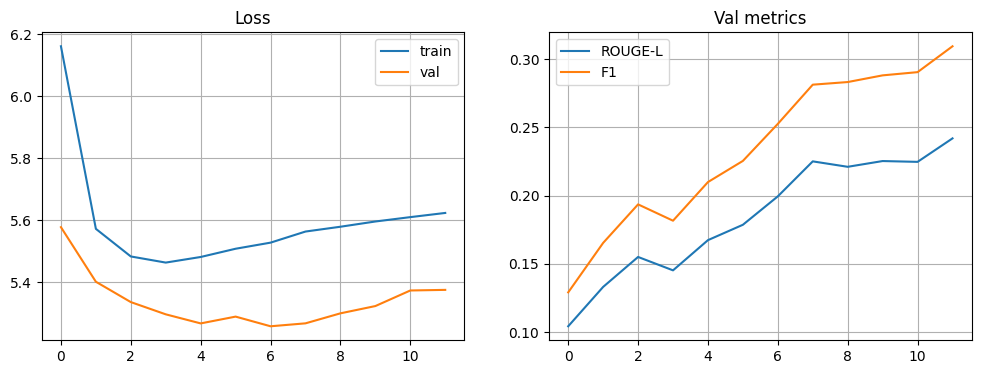

In [15]:
EARLY_PATIENCE = 4; MIN_DELTA = 1e-4
early_best = None; early_count = 0
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
best_ckpt = "artifacts/pic2a_noocr_best.pth"

his = {"train_loss":[], "val_loss":[], "rougeL":[], "EM":[], "F1":[]}

for epoch in range(1, TOTAL_EPOCHS+1):
    model.train()
    tf = tf_ratio(epoch-1)
    run_loss = 0.0
    pbar = tqdm(train_loader, desc=f"[A++] Epoch {epoch}/{TOTAL_EPOCHS} (TF={tf:.2f}, lr={scheduler.get_last_lr()[0]:.2e})")
    for batch in pbar:
        img = batch["image_feat"].to(device, non_blocking=True)
        q   = batch["q_ids"].to(device, non_blocking=True)
        a   = batch["a_ids"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, tgt = model(img, q, a_ids=a, teacher_forcing=tf)
            loss = criterion(logits, tgt)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        run_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.3f}")

    avg_tr = run_loss / max(1, len(train_loader))

    # ---- Validation loss ----
    model.eval(); val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            img = batch["image_feat"].to(device, non_blocking=True)
            q   = batch["q_ids"].to(device, non_blocking=True)
            a   = batch["a_ids"].to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits, tgt = model(img, q, a_ids=a, teacher_forcing=1.0)
                loss = criterion(logits, tgt)
            val_loss += loss.item()
    avg_val = val_loss / max(1, len(val_loader))

    # ---- Quick metrics on df_val ----
    model.eval()
    rows = df_val.sample(min(128, len(df_val)), random_state=SEED)
    rL_vals, EM_vals, F1_vals = [], [], []
    with torch.no_grad():
        for _, row in rows.iterrows():
            iid = str(row["image_id"]); q = str(row["question"]); ref = str(row["answer"])
            img = torch.tensor(get_feat(iid), dtype=torch.float32, device=device).unsqueeze(0)
            qid = torch.tensor([encode(q, vocab_q, LEN_Q)], dtype=torch.long, device=device)
            pred_ids = beam_search_decode(model, img, qid, beam_size=4, max_len=LEN_A, alpha=0.6)
            hyp = decode(pred_ids, itos_a)
            rL_vals.append(rougeL_f1(hyp, ref))
            em, f1 = exact_match_and_f1(hyp, ref)
            EM_vals.append(em); F1_vals.append(f1)

    rL = float(np.mean(rL_vals)); EM = float(np.mean(EM_vals)); F1 = float(np.mean(F1_vals))
    print(f"[A++] Epoch {epoch} | train {avg_tr:.4f} | val {avg_val:.4f} | ROUGE-L {rL:.4f} | EM {EM:.3f} | F1 {F1:.3f}")

    # history
    his["train_loss"].append(avg_tr); his["val_loss"].append(avg_val)
    his["rougeL"].append(rL); his["EM"].append(EM); his["F1"].append(F1)

    # save best + early stop
    if early_best is None or avg_val < early_best - MIN_DELTA:
        early_best = avg_val; early_count = 0
        torch.save(model.state_dict(), best_ckpt)
        print(f"  ↳ Saved best to {best_ckpt}")
    else:
        early_count += 1
        if early_count > EARLY_PATIENCE:
            print("  ↳ Early stopping triggered."); break

    scheduler.step()

# ----- Save last + curves -----
torch.save(model.state_dict(), "artifacts/pic2a_noocr_last.pth")
with open("artifacts/pic2a_noocr_curves.json","w") as f: json.dump(his, f)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(his["train_loss"],label="train"); plt.plot(his["val_loss"],label="val"); plt.grid(True); plt.legend(); plt.title("Loss")
plt.subplot(1,2,2); plt.plot(his["rougeL"],label="ROUGE-L"); plt.plot(his["F1"],label="F1"); plt.grid(True); plt.legend(); plt.title("Val metrics")
plt.show()

# NFERENCE & FINAL TEST

In [16]:
model.load_state_dict(torch.load(best_ckpt, map_location=device)); model.eval()

def predict_beam(image_id: str, question: str, beam=4):
    with torch.no_grad():
        img = torch.tensor(get_feat(str(image_id)), dtype=torch.float32, device=device).unsqueeze(0)
        qid = torch.tensor([encode(question, vocab_q, LEN_Q)], dtype=torch.long, device=device)
        pred_ids = beam_search_decode(model, img, qid, beam_size=beam, max_len=LEN_A, alpha=0.6)
        return decode(pred_ids, itos_a)

sample = df_val.iloc[0] if len(df_val)>0 else df_test_final.iloc[0]
print("SAMPLE | Q:", sample["question"])
print("SAMPLE | PRED:", predict_beam(sample["image_id"], sample["question"], beam=4))
print("SAMPLE | GT:", sample["answer"])

SAMPLE | Q: bài_toán số 6 sử_dụng hình_ảnh gì để minh họa
SAMPLE | PRED: bài_toán sử_dụng hình_ảnh minh_họa bài_toán tam_giác số 6 cho là một đường tròn với các cạnh ab và ac và bd bằng nhau
SAMPLE | GT: hình_minh họa trong bài_toán số 6 là một hình_chữ_nhật cắt đường tròn hình_chữ_nhật có chiều dài bằng 5 chiều rộng bằng 3 và được đánh_dấu các điểm a_b c d e_f đường tròn đi qua các điểm b c e_f và có tâm nằm giữa đoạn ef
